In [4]:

from datetime import datetime, timedelta
import numpy as np
import pandas as pd
# from ydata_profiling import ProfileReport
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# criando um caminho universal para que rode em qualquer maquina
pasta_atual = Path.cwd()
pasta_banco = pasta_atual.parent / 'database'


# importando os arquivos e modificando os tipos de dados

contas_df = pd.read_csv(pasta_banco/'account.asc', sep=';', dtype= {'account_id':str, 'district_id': str})
cartoes_df = pd.read_csv(pasta_banco/'card.asc', sep=';', dtype= {'card_id': str,'disp_id':str})
clientes_df = pd.read_csv(pasta_banco/'client.asc', sep=';', dtype= {'client_id':str,'district_id':str, 'birth_number': str})
cliente_conta_df = pd.read_csv(pasta_banco/'disp.asc', sep=';', dtype= {'disp_id':str, 'client_id':str,'account_id':str})
emprestimo_df = pd.read_csv(pasta_banco/'loan.asc', sep=';', dtype = {'loan_id':str,'account_id':str})
ordens_df = pd.read_csv(pasta_banco/'order.asc', sep=';', dtype = {'order_id':str,'account_id':str})
distrito_df = pd.read_csv(pasta_banco/'district.asc', sep=';',na_values=['?'] ,dtype = {'A1':str,'A11':float,'A12':float,'A15':'Int64'})
transacoes_df = pd.read_csv(pasta_banco/'trans.asc', sep=';',dtype={'trans_id' : str,'account_id' : str, 'bank':str}) 


# juntando colunas para realizar nosso star schema em algum programa de visualizaçao de dados e para aumentar a performance do banco de dados

# clientes_df + client_conta_df


In [6]:
transacoes_df

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,930101,PRIJEM,VKLAD,700.0,700.0,NaN,NaN,NaN
1,171812,576,930101,PRIJEM,VKLAD,900.0,900.0,NaN,NaN,NaN
2,207264,704,930101,PRIJEM,VKLAD,1000.0,1000.0,NaN,NaN,NaN
3,1117247,3818,930101,PRIJEM,VKLAD,600.0,600.0,NaN,NaN,NaN
4,579373,1972,930102,PRIJEM,VKLAD,400.0,400.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1056315,3626622,2906,981231,PRIJEM,NaN,62.3,13729.4,UROK,NaN,NaN
1056316,3627616,2935,981231,PRIJEM,NaN,81.3,19544.9,UROK,NaN,NaN
1056317,3625403,2869,981231,PRIJEM,NaN,60.2,14638.2,UROK,NaN,NaN
1056318,3626683,2907,981231,PRIJEM,NaN,107.5,23453.0,UROK,NaN,NaN


In [7]:
# Percentual de nulos — mais útil em bases grandes
print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
trans_id       0.00
account_id     0.00
date           0.00
type           0.00
operation     17.34
amount         0.00
balance        0.00
k_symbol      45.62
bank          74.11
account       72.04
dtype: float64


In [8]:
# print(distrito_df['crimes_cometidos_95'].unique())

In [9]:
# Recolhendo amostras 
transacoes_df.sample(20)

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
356915,991013,3378,960731,PRIJEM,VKLAD,2500.0,34184.6,NaN,NaN,NaN
800258,1476760,5033,980228,VYDAJ,VYBER,14.6,27175.0,SLUZBY,NaN,NaN
192531,162262,542,950731,VYDAJ,VYBER,14.6,16470.9,SLUZBY,NaN,NaN
954837,593204,2019,980831,VYDAJ,VYBER,14.6,14913.3,SLUZBY,NaN,NaN
776750,1121741,3832,980131,VYDAJ,VYBER,14.6,17366.0,SLUZBY,NaN,NaN
194475,953312,3250,950804,VYDAJ,VYBER,5300.0,23818.8,NaN,NaN,NaN
143425,3672084,5632,950228,PRIJEM,NaN,278.6,57702.5,UROK,NaN,NaN
955132,3623532,2814,980831,PRIJEM,NaN,130.0,32644.9,UROK,NaN,NaN
948072,2078247,7045,980831,VYDAJ,VYBER,14.6,49205.2,SLUZBY,NaN,NaN
628590,153984,516,970831,VYDAJ,VYBER,14.6,32410.7,SLUZBY,NaN,NaN


In [10]:
# Gerando relatorios dos dados 
transacoes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   trans_id    1056320 non-null  str    
 1   account_id  1056320 non-null  str    
 2   date        1056320 non-null  int64  
 3   type        1056320 non-null  str    
 4   operation   873206 non-null   str    
 5   amount      1056320 non-null  float64
 6   balance     1056320 non-null  float64
 7   k_symbol    574439 non-null   str    
 8   bank        273508 non-null   str    
 9   account     295389 non-null   float64
dtypes: float64(3), int64(1), str(6)
memory usage: 80.6 MB


In [11]:
# Estatisticas descritivas dos dados
transacoes_df.describe()

,date,amount,balance,account
count,1.056320e+06,1.056320e+06,1.056320e+06,2.953890e+05
mean,9.656748e+05,5.924146e+03,3.851833e+04,4.567092e+07
std,1.394535e+04,9.522735e+03,2.211787e+04,3.066340e+07
min,9.301010e+05,0.000000e+00,-4.112570e+04,0.000000e+00
25%,9.601160e+05,1.359000e+02,2.240250e+04,1.782858e+07
50%,9.704100e+05,2.100000e+03,3.314340e+04,4.575095e+07
75%,9.802280e+05,6.800000e+03,4.960362e+04,7.201341e+07
max,9.812310e+05,8.740000e+04,2.096370e+05,9.999420e+07


In [12]:
def descritivas(data):
  variaveis = data.select_dtypes(include=np.number)
  desc = variaveis.describe().T
  desc["CV"] = desc["std"]/desc["mean"]
  desc["Skew"] = variaveis.skew()
  desc["Kurtosis"] = variaveis.kurt()
  ordered_cols = [
      "count", "mean", "std", "CV",
      "min", "25%", "50%", "75%", "max",
      "Skew", "Kurtosis"
  ]
  desc = desc[ordered_cols]
  return desc.round(2)


In [13]:
# %%
# analise descritiva da coluna CL_FHL (quantidade de filhos por cliente)
descritivas(transacoes_df)

,count,mean,std,CV,min,25%,50%,75%,max,Skew,Kurtosis
date,1056320.0,965674.82,13945.35,0.01,930101.0,960116.0,970410.0,980228.00,981231.0,-0.69,-0.49
amount,1056320.0,5924.15,9522.74,1.61,0.0,135.9,2100.0,6800.00,87400.0,2.59,7.76
balance,1056320.0,38518.33,22117.87,0.57,-41125.7,22402.5,33143.4,49603.62,209637.0,1.23,1.88
account,295389.0,45670919.37,30663396.85,0.67,0.0,17828584.0,45750951.0,72013407.00,99994199.0,0.06,-1.25


In [14]:
# Linhas duplicadas

transacoes_df.duplicated().sum()

np.int64(0)

In [15]:
print('Quantidade de nulos por coluna:')
print(transacoes_df.isnull().sum())

Quantidade de nulos por coluna:
trans_id           0
account_id         0
date               0
type               0
operation     183114
amount             0
balance            0
k_symbol      481881
bank          782812
account       760931
dtype: int64


In [16]:
# Percentual de nulos — mais útil em bases grandes
# len(df) = número total de linhas
print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
trans_id       0.00
account_id     0.00
date           0.00
type           0.00
operation     17.34
amount         0.00
balance        0.00
k_symbol      45.62
bank          74.11
account       72.04
dtype: float64


### Tratamento de Datas

In [17]:
# Tratamento de datas na tabela de transacoes_df
# transformamos o número inteiro em texto (string)
transacoes_df['date'] = transacoes_df['date'].astype(str)

# convertendo para datetime usando o formato YYMMDD (padrão do banco Berka, conforme documentacao deste dataset)
transacoes_df['date'] = pd.to_datetime(
    transacoes_df['date'],
    format='%y%m%d',
    errors='coerce'
)


# ____________________________________________________________________________________

# Tratamento de datas na tabela de emprestimo_df
emprestimo_df['date'] = emprestimo_df['date'].astype(str)

emprestimo_df['date'] = pd.to_datetime(
    emprestimo_df['date'],
    format='%y%m%d',
    errors='coerce'
)

# ____________________________________________________________________________________

# Tratamento de datas na tabela de cartoes_df
cartoes_df['issued'] = cartoes_df['issued'].astype(str).str[:6]

cartoes_df['issued'] = pd.to_datetime(
    cartoes_df['issued'],
    format='%y%m%d',
    errors='coerce'
)
# ____________________________________________________________________________________

# Tratamento de datas na tabela de contas_df
contas_df['date'] = contas_df['date'].astype(str).str[:6]
contas_df['date'] = pd.to_datetime(
    contas_df['date'],
    format= '%y%m%d',
    errors='coerce'
)


# verificação rápida para garantir que funcionou e ver o real alcance dos dados
print(f"Data Mínima das Transações: {contas_df['date'].min()}")
print(f"Data Máxima das Transações: {contas_df['date'].max()}")

Data Mínima das Transações: 1993-01-01 00:00:00
Data Máxima das Transações: 1997-12-29 00:00:00


In [18]:
transacoes_df

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,1993-01-01,PRIJEM,VKLAD,700.0,700.0,NaN,NaN,NaN
1,171812,576,1993-01-01,PRIJEM,VKLAD,900.0,900.0,NaN,NaN,NaN
2,207264,704,1993-01-01,PRIJEM,VKLAD,1000.0,1000.0,NaN,NaN,NaN
3,1117247,3818,1993-01-01,PRIJEM,VKLAD,600.0,600.0,NaN,NaN,NaN
4,579373,1972,1993-01-02,PRIJEM,VKLAD,400.0,400.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1056315,3626622,2906,1998-12-31,PRIJEM,NaN,62.3,13729.4,UROK,NaN,NaN
1056316,3627616,2935,1998-12-31,PRIJEM,NaN,81.3,19544.9,UROK,NaN,NaN
1056317,3625403,2869,1998-12-31,PRIJEM,NaN,60.2,14638.2,UROK,NaN,NaN
1056318,3626683,2907,1998-12-31,PRIJEM,NaN,107.5,23453.0,UROK,NaN,NaN


In [19]:
# Tratamento de datas na tabela de client_df

clientes_df['birth_number'] = clientes_df['birth_number'].str.zfill(6)

# criando variaveis para que recebam o dia,ano,mes fatiado para facilitar a analise e tratamento
# e alterando o tipo de dados para realizar 

ano = clientes_df['birth_number'].str[:2]
mes = clientes_df['birth_number'].str[2:4].astype(int)
dia = clientes_df['birth_number'].str[4:]

# iremos criar a coluna o genero dos clientes com base no mes

clientes_df['gender'] = np.where(mes > 50, 'F', 'M')

# arrumando o mes para que ele retorne se somente for mulher

mes_limpo = np.where(mes > 50, mes - 50, mes)

# Volta o mês para texto com 2 dígitos (para que o mês 8 volte a ser '08')

mes_limpo_str = pd.Series(mes_limpo).astype(str).str.zfill(2)

# remontando a data e convertendo para datetime e forçando a inserçao do seculo, estipulando que os clientes nasceram no seculo 19

clientes_df['birth_date'] = pd.to_datetime('19' + ano + mes_limpo_str + dia, format='%Y%m%d')

# coluna original birth_date apagada 
clientes_df = clientes_df.drop(columns=['birth_number'])

### Criando dimCalendario

In [20]:

# identificando o ano inial e final para criar a tabela dim calendario
ano_inicio = transacoes_df['date'].min().year
ano_fim = transacoes_df['date'].max().year

# 2. Definir o intervalo completo (01/Jan do primeiro ano até 31/Dez do último ano)
data_inicio_completa = f'{ano_inicio}-01-01'
data_fim_completa = f'{ano_fim}-12-31'

# 3. Criar a sequência contínua de dias
datas_calendario = pd.date_range(start=data_inicio_completa, end=data_fim_completa)

# 4. Criar o DataFrame da dCalendario
dimCalendario = pd.DataFrame({'date': datas_calendario})

# 5. Extrair as colunas derivadas de forma segura (usando a própria dimCalendario)
dimCalendario['date_year'] = dimCalendario['date'].dt.year
dimCalendario['date_month'] = dimCalendario['date'].dt.month
dimCalendario['date_quarter'] = dimCalendario['date'].dt.quarter
dimCalendario['date_year_month'] = dimCalendario['date'].dt.strftime('%Y-%m')
dimCalendario['date_week'] = dimCalendario['date'].dt.isocalendar().week
dimCalendario['date_day'] = dimCalendario['date'].dt.day
dimCalendario['date_day_name'] = dimCalendario['date'].dt.day_name()

# Visualizar o resultado final do calendário
dimCalendario

,date,date_year,date_month,date_quarter,date_year_month,date_week,date_day,date_day_name
0,1993-01-01,1993,1,1,1993-01,53,1,Friday
1,1993-01-02,1993,1,1,1993-01,53,2,Saturday
2,1993-01-03,1993,1,1,1993-01,53,3,Sunday
3,1993-01-04,1993,1,1,1993-01,1,4,Monday
4,1993-01-05,1993,1,1,1993-01,1,5,Tuesday
...,...,...,...,...,...,...,...,...
2186,1998-12-27,1998,12,4,1998-12,52,27,Sunday
2187,1998-12-28,1998,12,4,1998-12,53,28,Monday
2188,1998-12-29,1998,12,4,1998-12,53,29,Tuesday
2189,1998-12-30,1998,12,4,1998-12,53,30,Wednesday


### Correcao de Inconsistencias e traduçao de linhas e colunas

In [21]:
# tabela contas_df

contas_df = contas_df.rename(columns={
    'account_id': 'id_conta',
    'district_id': 'id_distrito',
    'date': 'data',
    'frequency': 'frequencia'
})

ajustar = {
    'POPLATEK MESICNE': 'emissao_mensal',
    'POPLATEK PO OBRATU': 'emissao_semanal',
    'POPLATEK TYDNE': 'emissao_pos_transacao'
}


contas_df['frequencia'] = contas_df['frequencia'].replace(ajustar)
contas_df.head(2)

,id_conta,id_distrito,frequencia,data
0,576,55,emissao_mensal,1993-01-01
1,3818,74,emissao_mensal,1993-01-01


In [22]:
# tabela contas_df

cartoes_df = cartoes_df.rename(columns={
    'card_id': 'id_cartao',
    'disp_id': 'id_disp',
    'type': 'tipo_cartao',
    'issued': 'data'
})


cartoes_df.sample(10)

,id_cartao,id_disp,tipo_cartao,data
624,440,2782,classic,1998-07-07
491,529,3357,classic,1998-02-27
483,574,3640,junior,1998-02-23
859,306,1929,classic,1998-12-11
722,880,7186,classic,1998-09-17
882,924,7862,classic,1998-12-24
853,341,2156,gold,1998-12-06
120,204,1239,junior,1996-05-30
353,767,5204,classic,1997-09-14
599,785,5468,classic,1998-06-16


In [23]:
# tabela clientes_df

clientes_df = clientes_df.rename(columns={
    'client_id': 'id_cliente',
    'district_id': 'id_distrito',
    'gender': 'genero',
    'birth_date': 'data_nascimento'
})




clientes_df.sample(10)

,id_cliente,id_distrito,genero,data_nascimento
1475,1563,3,M,1978-08-06
104,113,1,F,1940-08-15
2858,3018,61,M,1978-01-28
5255,12397,62,M,1973-06-02
5212,11860,70,F,1925-08-30
2410,2539,32,F,1972-01-21
2241,2368,64,F,1943-12-22
2388,2517,18,M,1924-09-09
2644,2798,65,M,1931-06-27
43,46,19,F,1940-01-30


In [24]:
# tabela cliente_conta_df

cliente_conta_df = cliente_conta_df.rename(columns={
    'disp_id	': 'id_disp',
    'client_id': 'id_cliente',
    'account_id': 'id_conta',
    'type': 'tipo_acesso'
})

ajustar = {
    'OWNER': 'proprietario',
    'DISPONENT': 'usuario'
}

cliente_conta_df['tipo_acesso'] = cliente_conta_df['tipo_acesso'].replace(ajustar)
cliente_conta_df.sample(10)


,disp_id,id_cliente,id_conta,tipo_acesso
3221,3403,3403,2816,usuario
5011,9120,9428,7614,usuario
1992,2107,2107,1736,usuario
309,329,329,272,proprietario
4141,4380,4380,3631,proprietario
3247,3431,3431,2839,proprietario
4448,4707,4707,3903,usuario
2120,2238,2238,1845,usuario
3873,4091,4091,3383,proprietario
1605,1699,1699,1403,proprietario


In [25]:
# tabela emprestimo_df

emprestimo_df = emprestimo_df.rename(columns={
    'loan_id': 'id_emprestimo',
    'account_id': 'id_conta',
    'date': 'data',
    'amount': 'valor_total',
    'duration': 'prazo_meses',
    'payments': 'valor_parcela',
    'status': 'status_pagamento'
})

ajustar = {
    'A': 'quitado_regular',
    'B': 'inadimplente',
    'C': 'em andamento_regular',
    'D': 'em andamento_crédito_defectivo'
}


emprestimo_df['status_pagamento'] = emprestimo_df['status_pagamento'].replace(ajustar)
emprestimo_df.sample(10)

,id_emprestimo,id_conta,data,valor_total,prazo_meses,valor_parcela,status_pagamento
82,6038,5120,1994-08-10,323472,48,6739.0,quitado_regular
299,6644,8039,1996-10-20,93600,24,3900.0,quitado_regular
243,5892,4462,1996-05-14,66480,24,2770.0,inadimplente
163,5713,3629,1995-05-30,158760,60,2646.0,em andamento_regular
516,5043,339,1997-12-25,468060,60,7801.0,em andamento_regular
505,4962,25,1997-12-08,30276,12,2523.0,quitado_regular
369,7046,10049,1997-03-28,91632,12,7636.0,quitado_regular
404,6908,9353,1997-06-08,188616,24,7859.0,em andamento_regular
132,5724,3678,1995-02-05,316140,60,5269.0,em andamento_crédito_defectivo
485,6242,6097,1997-10-22,26208,36,728.0,em andamento_regular


In [26]:
# tabela ordens_df

ordens_df = ordens_df.rename(columns={
    'order_id': 'id_ordem',
    'account_id': 'id_conta',
    'bank_to': 'banco_destino',
    'account_to': 'conta_destino',
    'amount': 'valor_debito',
    'k_symbol': 'categoria_pagamento'
})

ajustar = {
    'SIPO': 'Despesas Domesticas',
    'UVER': 'Parcela de Emprestimo',
    'POJISTNE': 'Pagamento de Seguro',
    'LEASING': 'Financiamento de Veículos e Máquinas'
}


ordens_df['categoria_pagamento'] = ordens_df['categoria_pagamento'].replace(ajustar)
ordens_df.sample(10)

,id_ordem,id_conta,banco_destino,conta_destino,valor_debito,categoria_pagamento
3378,33137,2527,YZ,75348806,2322.6,Financiamento de Veículos e Máquinas
6376,45326,10711,WX,75319576,85.0,Pagamento de Seguro
3960,33773,2952,YZ,60263645,1629.0,Despesas Domesticas
5205,35168,3912,UV,99253552,1177.0,Despesas Domesticas
5890,40566,7546,EF,8914953,3861.0,Despesas Domesticas
3810,33613,2841,AB,5304688,3536.0,Despesas Domesticas
2024,31638,1515,QR,23320967,2907.0,Pagamento de Seguro
2406,32058,1813,QR,343406,4350.0,
2889,32579,2166,UV,73421168,5263.0,Pagamento de Seguro
3639,33422,2721,QR,69068598,1544.0,Despesas Domesticas


In [27]:
# tabela distrito_df

distrito_df = distrito_df.rename(columns={
    'A1': 'id_distrito',
    'A2': 'nome_distrito',
    'A3': 'regiao',
    'A4': 'num_habitantes',
    'A5': 'municipios_ate_499_hab',
    'A6': 'municipios_500_1999_hab',
    'A7': 'municipios_2000_9999_hab',
    'A8': 'municipios_mais_10000_hab',
    'A9': 'num_cidades',
    'A10': 'proporcao_populacao_urbana',
    'A11': 'salario_medio',
    'A12': 'taxa_desemprego_95',
    'A13': 'taxa_desemprego_96',
    'A14': 'num_empreendedores_por_1000_hab',
    'A15': 'crimes_cometidos_95',
    'A16': 'crimes_cometidos_96'
})


distrito_df['regiao'] = distrito_df['regiao'].str.capitalize()

distrito_df.sample(10)

,id_distrito,nome_distrito,regiao,num_habitantes,municipios_ate_499_hab,municipios_500_1999_hab,municipios_2000_9999_hab,municipios_mais_10000_hab,num_cidades,proporcao_populacao_urbana,salario_medio,taxa_desemprego_95,taxa_desemprego_96,num_empreendedores_por_1000_hab,crimes_cometidos_95,crimes_cometidos_96
37,38,Louny,North bohemia,85852,41,23,4,2,4,59.8,8965.0,7.08,8.23,104,2653,2822
62,63,Vyskov,South moravia,86513,38,36,5,1,5,50.5,8288.0,3.79,4.52,110,1562,1460
21,22,Domazlice,West bohemia,58400,65,16,4,1,6,52.4,8620.0,1.10,1.25,100,1089,1117
8,9,Nymburk,Central bohemia,81344,61,23,4,2,6,55.3,8899.0,3.39,3.97,149,2987,2487
17,18,Pisek,South bohemia,70699,60,13,2,1,4,65.3,8968.0,2.83,3.35,131,1740,1910
45,46,Nachod,East bohemia,112709,48,20,7,3,10,73.5,8369.0,1.79,2.31,117,2854,2618
4,5,Kolin,Central bohemia,95616,65,30,4,1,6,51.4,9307.0,3.85,4.43,118,2616,3040
71,72,Olomouc,North moravia,226122,32,50,7,4,4,62.6,8994.0,3.80,4.79,110,9672,9208
13,14,Ceske Budejovice,South bohemia,177686,69,27,10,1,9,74.8,10045.0,1.42,1.71,135,6604,6295
44,45,Jicin,East bohemia,77917,85,19,6,1,5,53.5,8390.0,2.28,2.89,132,2080,2122


In [28]:
# tabela ordens_df

transacoes_df = transacoes_df.rename(columns={
    'trans_id': 'id_transacao',
    'account_id': 'id_conta',
    'date': 'data',
    'type': 'tipo_movimentacao',
    'operation': 'modo_operacao',
    'amount': 'valor_transacao',
    'balance': 'saldo_apos_transacao',
    'k_symbol': 'categoria_transacao',
    'bank': 'banco_parceiro',
    'account': 'conta_parceiro'
})

tipo_mov = {
    'PRIJEM': 'Credito (+)',
    'VYDAJ': 'Debito (-)',
    'VYBER': 'Debito (-)'
}


tipo_ope = {
    'VKLAD': 'Deposito em Dinheiro',
    'PREVOD Z UCTU': 'Transferencia Recebida',
    'VYBER': 'Saque em Dinheiro',
    'PREVOD NA UCET': 'Transferencia Enviada',
    'VYBER KARTOU': 'Saque com Cartao'
}

tipo_trans ={
    'POJISTNE': 'Pagamento de Seguro',
    'SLUZBY': 'Tarifa Bancaria',
    'UROK': 'Juros Recebidos',
    'SANKC. UROK': 'Juros de Multa',
    'SIPO': 'Contas de Consumo',
    'DUCHOD': 'Aposentadoria / Pensao',
    'UVER': 'Parcela de Emprestimo'
}




transacoes_df['tipo_movimentacao'] = transacoes_df['tipo_movimentacao'].replace(tipo_mov)
transacoes_df['modo_operacao'] = transacoes_df['modo_operacao'].replace(tipo_ope)
transacoes_df['categoria_transacao'] = transacoes_df['categoria_transacao'].replace(tipo_trans)
transacoes_df.sample(2)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
452133,1078707,3684,1997-01-04,Debito (-),Saque em Dinheiro,1400.0,20865.3,NaN,NaN,NaN
860025,901192,3071,1998-05-11,Credito (+),Deposito em Dinheiro,24266.0,60605.3,NaN,NaN,NaN


In [29]:
# Percentual de nulos — mais útil em bases grandes
# len(df) = número total de linhas
print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao             0.00
id_conta                 0.00
data                     0.00
tipo_movimentacao        0.00
modo_operacao           17.34
valor_transacao          0.00
saldo_apos_transacao     0.00
categoria_transacao     45.62
banco_parceiro          74.11
conta_parceiro          72.04
dtype: float64


### Tratamento de Missing Values

In [30]:
# Definindo valores substitutos que fazem sentido para o negócio do banco

# tabela transacoes_df

valores_substitutos = {
    'modo_operacao': 'Sistema / Automático',
    'categoria_transacao': 'Movimentação Geral',
    'banco_parceiro': 'Não se aplica (Interno)',
    'conta_parceiro': 'Não se aplica (Interno)'
}

# Aplicando nosso dicionario para preencher Missing Values
transacoes_df = transacoes_df.fillna(value=valores_substitutos)

In [31]:
# Percentual de nulos — mais útil em bases grandes  (POS PROCESSAMENTO DOS NULOS)

print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao            0.0
id_conta                0.0
data                    0.0
tipo_movimentacao       0.0
modo_operacao           0.0
valor_transacao         0.0
saldo_apos_transacao    0.0
categoria_transacao     0.0
banco_parceiro          0.0
conta_parceiro          0.0
dtype: float64


In [32]:
# Iremos preencher os Missing Values com medo de Imputaçao Estratificada preenchendo a taxa de desemprego com a mediana da própria região daquele distrito

# 1. Transformamos temporariamente para float para aceitar as medianas do groupby
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].astype(float)

# 2. Agora aplicamos a imputação estratificada (vai rodar sem reclamar)
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].fillna(
    distrito_df.groupby('regiao')['crimes_cometidos_95'].transform('median')
)

# 3. Como não existe "meio crime", limpamos a coluna transformando-a em inteiro puro
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].astype(int)

# Aplicando a imputação estratificada na taxa de desemprego de 95
distrito_df['taxa_desemprego_95'] = distrito_df['taxa_desemprego_95'].fillna(
    distrito_df.groupby('regiao')['taxa_desemprego_95'].transform('median')
)


### Tratamento de Outliers

In [33]:
# Imputaçao Estratificada

transacoes_df_copy = transacoes_df


# Identificacao de Outliers com IQR

outliers = {}

# Filtragem por IQR

for col in transacoes_df_copy.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = transacoes_df_copy[col].quantile(0.25)
    Q3 = transacoes_df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    filtro = (transacoes_df_copy[col] < limite_inferior) | (transacoes_df_copy[col] > limite_superior)
    count = filtro.sum()

    # Contagem de Outliers por coluna

    if count > 0:
        menor_valor = transacoes_df_copy.loc[filtro, col].min()
        maior_valor = transacoes_df_copy.loc[filtro, col].max()
    else:
        maior_valor = None
        menor_valor = None
    
    # Construindo um dataframe com os Outliers encontrados

    outliers[col] = {
        'Contagem de Outliers': count,
        '% de Outliers': ((count / len(transacoes_df_copy)) * 100).round(3),
        'Limite Inferior': limite_inferior.round(3),
        'Limite Superior': limite_superior.round(3),
        'Maior outlier': maior_valor,
        'Menor outlier': menor_valor
    }


outlier_df = pd.DataFrame.from_dict(outliers, orient='index')
outlier_df.head()

,Contagem de Outliers,% de Outliers,Limite Inferior,Limite Superior,Maior outlier,Menor outlier
valor_transacao,120215,11.381,-9860.250,16796.150,87400.0,16797.0
saldo_apos_transacao,34806,3.295,-18399.188,90405.312,209637.0,-41125.7


In [34]:
outlier_df.describe()

,Contagem de Outliers,% de Outliers,Limite Inferior,Limite Superior,Maior outlier,Menor outlier
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,77510.500000,7.338000,-14129.719000,53600.731000,148518.500000,-12164.350000
std,60393.283074,5.717665,6037.940964,52049.537608,86434.611612,40957.533955
min,34806.000000,3.295000,-18399.188000,16796.150000,87400.000000,-41125.700000
25%,56158.250000,5.316500,-16264.453500,35198.440500,117959.250000,-26645.025000
50%,77510.500000,7.338000,-14129.719000,53600.731000,148518.500000,-12164.350000
75%,98862.750000,9.359500,-11994.984500,72003.021500,179077.750000,2316.325000
max,120215.000000,11.381000,-9860.250000,90405.312000,209637.000000,16797.000000


In [35]:
distrito_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_distrito                      77 non-null     str    
 1   nome_distrito                    77 non-null     str    
 2   regiao                           77 non-null     str    
 3   num_habitantes                   77 non-null     int64  
 4   municipios_ate_499_hab           77 non-null     int64  
 5   municipios_500_1999_hab          77 non-null     int64  
 6   municipios_2000_9999_hab         77 non-null     int64  
 7   municipios_mais_10000_hab        77 non-null     int64  
 8   num_cidades                      77 non-null     int64  
 9   proporcao_populacao_urbana       77 non-null     float64
 10  salario_medio                    77 non-null     float64
 11  taxa_desemprego_95               77 non-null     float64
 12  taxa_desemprego_96               77

In [36]:
print(distrito_df['taxa_desemprego_95'].unique())

[0.29 1.67 1.95 4.64 3.85 2.95 2.26 1.25 3.39 0.56 0.45 3.83 2.77 1.42
 3.13 1.12 2.38 2.83 2.65 1.51 1.1  1.79 1.39 2.47 2.64 0.65 1.62 2.82
 3.38 3.52 2.8  5.75 6.43 1.02 3.33 4.46 7.08 7.34 6.49 3.32 2.41 1.72
 2.79 2.28 1.78 1.89 4.83 2.51 2.52 2.53 1.6  1.88 4.69 3.73 3.24 3.45
 4.76 1.29 3.79 5.74 3.51 5.77 4.09 4.74 6.63 5.93 3.8  4.75 5.38 4.73
 4.01]


In [37]:
# Indentificando a distribuiçao de Missing Values

(distrito_df.isnull().sum()*100/distrito_df.index.size).round(2).sort_values(ascending=False)

id_distrito                        0.0
nome_distrito                      0.0
regiao                             0.0
num_habitantes                     0.0
municipios_ate_499_hab             0.0
municipios_500_1999_hab            0.0
municipios_2000_9999_hab           0.0
municipios_mais_10000_hab          0.0
num_cidades                        0.0
proporcao_populacao_urbana         0.0
salario_medio                      0.0
taxa_desemprego_95                 0.0
taxa_desemprego_96                 0.0
num_empreendedores_por_1000_hab    0.0
crimes_cometidos_95                0.0
crimes_cometidos_96                0.0
dtype: float64

In [39]:
#Calculando a Skewness

import scipy.stats as stats

g1 = stats.skew(transacoes_df_copy['valor_transacao'])

print(f'A skewness da valor_transacao é {g1}')

A skewness da valor_transacao é 2.590640386812571


In [ ]:
#Função de análise gráfica

def comparar_variavel(dados, var_quantitativa, var_categorica):

    plt.figure(figsize=(14, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(data=dados, x=var_categorica, y=var_quantitativa)
    plt.title(f'Boxplot de {var_quantitativa} por {var_categorica}')
    plt.xticks()

    # KDE Plot
    plt.subplot(1, 2, 2)

    for categoria in dados[var_categorica].unique():
        subset = dados[dados[var_categorica] == categoria]
        sns.kdeplot(subset[var_quantitativa], label=categoria, fill=True, alpha=0.3)

    plt.title(f'Distribuição de {var_quantitativa} por {var_categorica}')
    plt.legend()

    plt.tight_layout()
    plt.show()

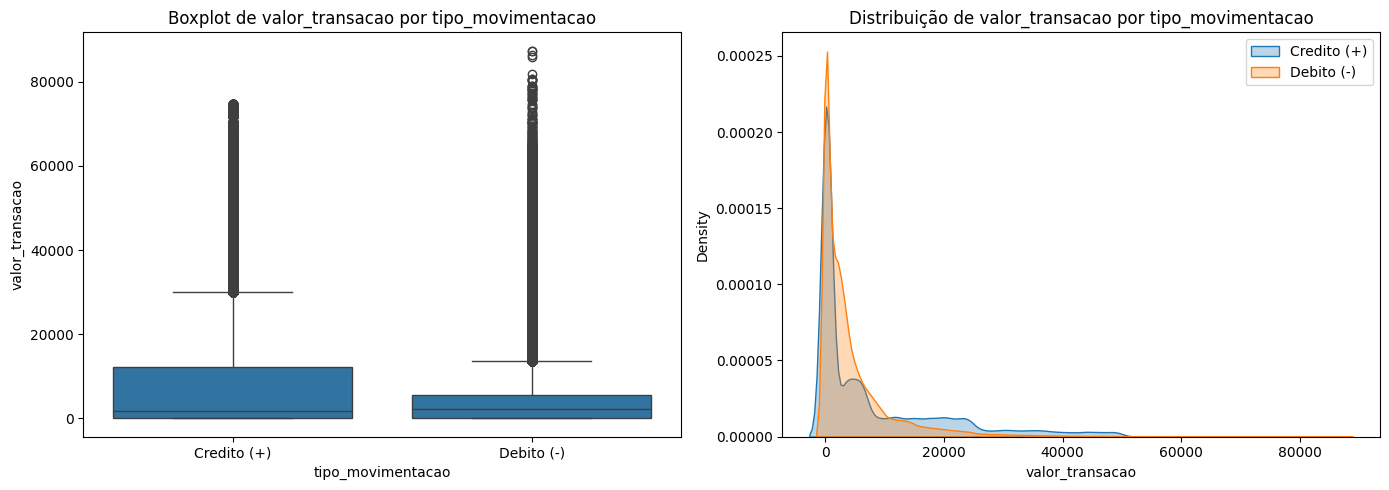

In [40]:
#Aplicação da função

comparar_variavel(transacoes_df, var_quantitativa = 'valor_transacao', var_categorica='tipo_movimentacao')